# Predictive Maintenance in Solar Power System using Machine Learning

## Objective

The goal of this project is to predict solar power generation using environmental and sensor data, and detect maintenance requirements by comparing predicted and actual power output.

If the deviation is high, the system flags a maintenance alert.

## Use Cases

- Solar plant monitoring
- Predictive maintenance
- Fault detection
- Efficiency optimization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [2]:
generation = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

In [3]:
generation.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [4]:
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [5]:
generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'], dayfirst=True)
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

In [6]:
data = pd.merge(generation, weather, on="DATE_TIME")
print(data.shape)

(68774, 12)


In [7]:
data = pd.merge(
    generation,
    weather,
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

In [8]:
print(data.shape)
print(data.head())

(68774, 11)
   DATE_TIME  PLANT_ID     SOURCE_KEY_x  DC_POWER  AC_POWER  DAILY_YIELD  \
0 2020-05-15   4135001  1BY6WEcLGh8j5v7       0.0       0.0          0.0   
1 2020-05-15   4135001  1IF53ai7Xc0U56Y       0.0       0.0          0.0   
2 2020-05-15   4135001  3PZuoBAID5Wc2HD       0.0       0.0          0.0   
3 2020-05-15   4135001  7JYdWkrLSPkdwr4       0.0       0.0          0.0   
4 2020-05-15   4135001  McdE0feGgRqW7Ca       0.0       0.0          0.0   

   TOTAL_YIELD     SOURCE_KEY_y  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  \
0    6259559.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
1    6183645.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
2    6987759.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
3    7602960.0  HmiyD2TTLFNqkNe            25.184316           22.857507   
4    7158964.0  HmiyD2TTLFNqkNe            25.184316           22.857507   

   IRRADIATION  
0          0.0  
1          0.0  
2          0.0  
3     

In [9]:
data = data[data['IRRADIATION'] > 0]

In [10]:
print(data.shape)

(38376, 11)


In [11]:
X = data[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]
y = data['AC_POWER']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [13]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
predicted = model.predict(X_test)

===== SAMPLE OUTPUT =====
   Actual Power  Predicted Power          Status
0   1128.537500      1112.507918  ✅ Working Fine
1    194.762500       195.087726  ✅ Working Fine
2   1284.012500      1270.001390  ✅ Working Fine
3    498.162500       519.492939  ✅ Working Fine
4     66.471429        64.140408  ✅ Working Fine
5    771.928571       714.919529  ✅ Working Fine
6    763.887500       750.229372  ✅ Working Fine
7   1213.557143      1208.767516  ✅ Working Fine
8     23.385714        22.834822  ✅ Working Fine
9    258.237500       260.936007  ✅ Working Fine


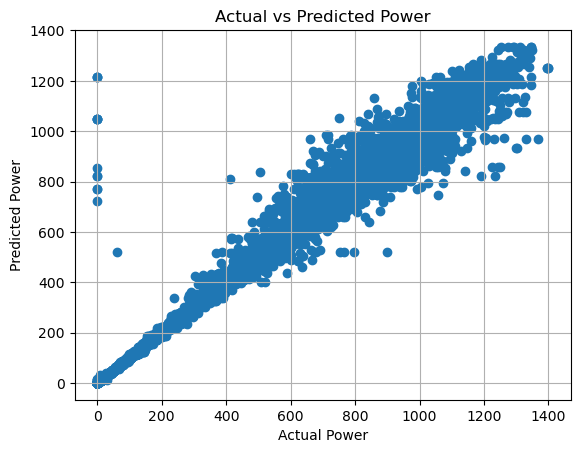


Mean Squared Error: 4080.780157627874


In [15]:
# ================================
# FINAL PREDICTION + MAINTENANCE + GRAPH
# ================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prediction
predicted = model.predict(X_test)

# Convert to numpy (safe)
y_actual = np.array(y_test)

# Maintenance Logic (safe division)
threshold = 0.2
status = []

for actual, pred in zip(y_actual, predicted):
    if actual == 0:
        status.append("⚠️ Low Output")
    elif abs(actual - pred) / actual > threshold:
        status.append("⚠️ Maintenance Required")
    else:
        status.append("✅ Working Fine")

# Create Result Table
results = pd.DataFrame({
    "Actual Power": y_actual,
    "Predicted Power": predicted,
    "Status": status
})

# Show top results
print("===== SAMPLE OUTPUT =====")
print(results.head(10))

# ================================
# GRAPH VISUALIZATION
# ================================

plt.figure()
plt.scatter(y_actual, predicted)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Power")
plt.grid()
plt.show()

# ================================
# BASIC ACCURACY CHECK
# ================================

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_actual, predicted)
print("\nMean Squared Error:", mse)

===== SAMPLE OUTPUT =====
        Actual    Predicted        Status
0  1128.537500  1108.497571  Working Fine
1   194.762500   188.918402  Working Fine
2  1284.012500  1270.557884  Working Fine
3   498.162500   519.434673  Working Fine
4    66.471429    64.129703  Working Fine
5   771.928571   736.618878  Working Fine
6   763.887500   778.653656  Working Fine
7  1213.557143  1210.198447  Working Fine
8    23.385714    22.720505  Working Fine
9   258.237500   254.995647  Working Fine


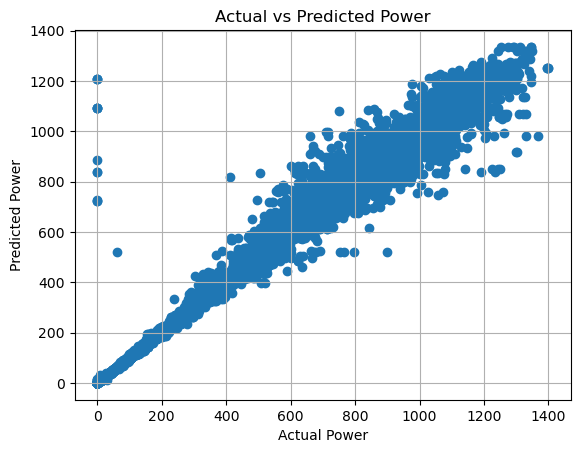

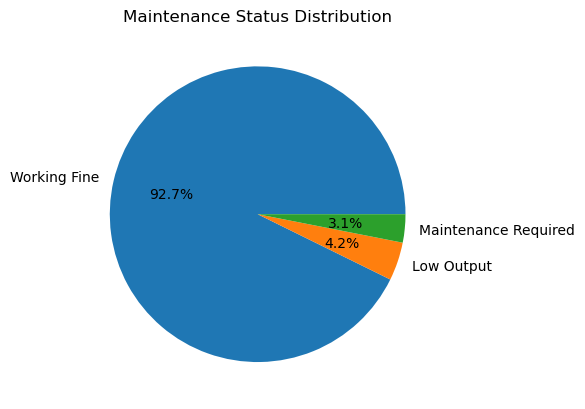


Mean Squared Error: 4267.577893155337
R2 Score (Accuracy): 0.9704111330672512


In [16]:
# ==========================================
# FINAL ADVANCED SOLAR MAINTENANCE SYSTEM
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ======================
# TRAIN BETTER MODEL
# ======================

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

# ======================
# PREDICTION
# ======================

predicted = model.predict(X_test)
y_actual = np.array(y_test)

# ======================
# MAINTENANCE LOGIC
# ======================

threshold = 0.2
status = []

for actual, pred in zip(y_actual, predicted):
    if actual == 0:
        status.append("Low Output")
    elif abs(actual - pred) / actual > threshold:
        status.append("Maintenance Required")
    else:
        status.append("Working Fine")

# ======================
# RESULT TABLE
# ======================

results = pd.DataFrame({
    "Actual": y_actual,
    "Predicted": predicted,
    "Status": status
})

print("===== SAMPLE OUTPUT =====")
print(results.head(10))

# ======================
# GRAPH 1: ACTUAL vs PREDICTED
# ======================

plt.figure()
plt.scatter(y_actual, predicted)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Power")
plt.grid()
plt.show()

# ======================
# GRAPH 2: PIE CHART (🔥)
# ======================

status_counts = results["Status"].value_counts()

plt.figure()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%')
plt.title("Maintenance Status Distribution")
plt.show()

# ======================
# ACCURACY CHECK
# ======================

mse = mean_squared_error(y_actual, predicted)
r2 = r2_score(y_actual, predicted)

print("\nMean Squared Error:", mse)
print("R2 Score (Accuracy):", r2)

In [17]:
print(results.sample(10))

           Actual    Predicted        Status
5232   763.128571   767.366017  Working Fine
1301    56.225000    61.021147  Working Fine
1560   573.787500   607.231122  Working Fine
6297   661.914286   676.841707  Working Fine
2405   108.837500   107.542005  Working Fine
5441   706.357143   693.964291  Working Fine
1468  1040.200000  1038.108351  Working Fine
2444   595.462500   575.960482  Working Fine
4699   112.050000   105.820278  Working Fine
1182  1156.200000  1098.159554  Working Fine


In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
import pandas as pd

generation_data = pd.read_csv("Plant_1_Generation_Data.csv")
weather_data = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

In [21]:
generation_data['DATE_TIME'] = pd.to_datetime(
    generation_data['DATE_TIME']
)

weather_data['DATE_TIME'] = pd.to_datetime(
    weather_data['DATE_TIME']
)

C:\Users\AARYA PATEL\AppData\Local\Temp\ipykernel_7488\3437199829.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation_data['DATE_TIME'] = pd.to_datetime(


In [22]:
merged_data = pd.merge(
    generation_data,
    weather_data,
    on='DATE_TIME'
)

In [23]:
merged_data.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [24]:
features = [
    'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE',
    'IRRADIATION',
    'DC_POWER'
]

target = 'AC_POWER'

X = merged_data[features]
y = merged_data[target]

In [25]:
X = X.fillna(X.mean())
y = y.fillna(y.mean())

In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.1,
    random_state=42
)

In [28]:
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1))

C:\Users\AARYA PATEL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

In [30]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 28044.5293 - mae: 74.1234 - val_loss: 731.8407 - val_mae: 12.2474
Epoch 2/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 4220.4668 - mae: 33.9625 - val_loss: 268.0271 - val_mae: 7.7460
Epoch 3/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3882.2000 - mae: 32.0187 - val_loss: 318.5144 - val_mae: 10.1300
Epoch 4/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3750.3618 - mae: 31.0196 - val_loss: 89.2689 - val_mae: 5.0031
Epoch 5/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 3661.7825 - mae: 30.5575 - val_loss: 29.4303 - val_mae: 2.5224
Epoch 6/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3608.5400 - mae: 30.1365 - val_loss: 25.9368 - val_mae: 2.7899
Epoch 7/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3584.3689 - mae: 29.8043 - val_loss: 10.3168 - val_mae: 1.9955
Epoch 8/50
1548/1548 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 3562.4932 - mae: 29.6637 - val_loss: 305.5704 - val_mae

In [32]:
predicted = model.predict(X_test)

predicted = predicted.flatten()

215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [33]:
mae = mean_absolute_error(y_test, predicted)
mse = mean_squared_error(y_test, predicted)
r2 = r2_score(y_test, predicted)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 21.557591201112235
MSE: 556.6012551904917
R2 Score: 0.9963832714881122


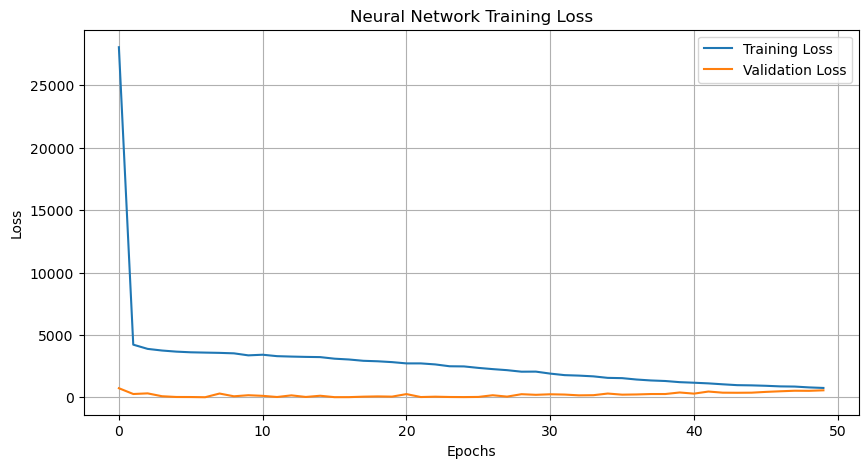

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Neural Network Training Loss')

plt.legend()
plt.grid(True)

plt.show()

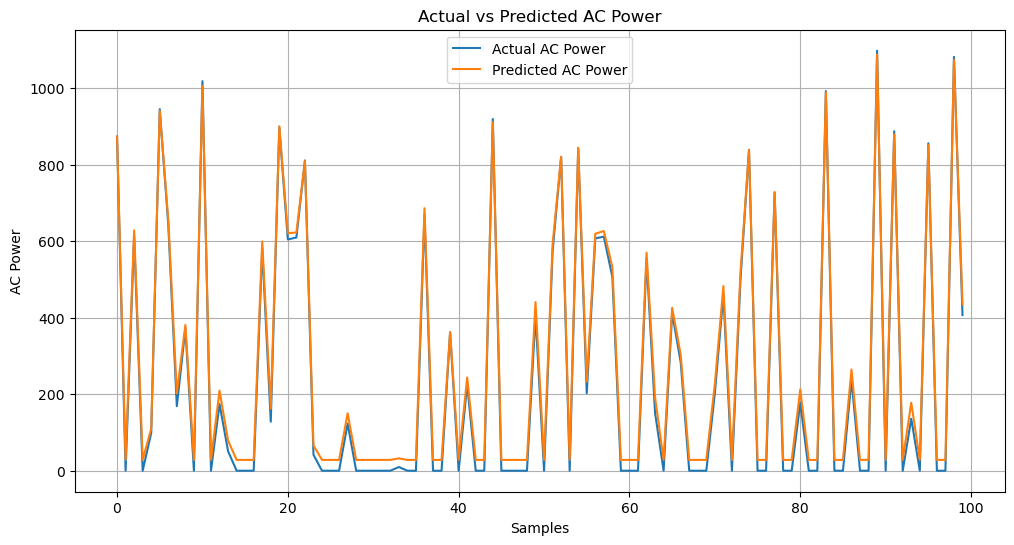

In [35]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:100], label='Actual AC Power')
plt.plot(predicted[:100], label='Predicted AC Power')

plt.xlabel('Samples')
plt.ylabel('AC Power')

plt.title('Actual vs Predicted AC Power')

plt.legend()
plt.grid(True)

plt.show()

In [36]:
results = pd.DataFrame({
    'Actual_AC_Power': y_test.values,
    'Predicted_AC_Power': predicted
})

results['Difference'] = abs(
    results['Actual_AC_Power'] -
    results['Predicted_AC_Power']
)

threshold = (
    results['Difference'].mean() +
    results['Difference'].std()
)

results['Maintenance_Required'] = (
    results['Difference'] > threshold
)

print(results.head())

   Actual_AC_Power  Predicted_AC_Power  Difference  Maintenance_Required
0       873.237500          873.485657    0.248157                 False
1         0.000000           28.255024   28.255024                 False
2       613.785714          628.130920   14.345206                 False
3         0.000000           28.251616   28.251616                 False
4        98.628571          110.011101   11.382529                 False


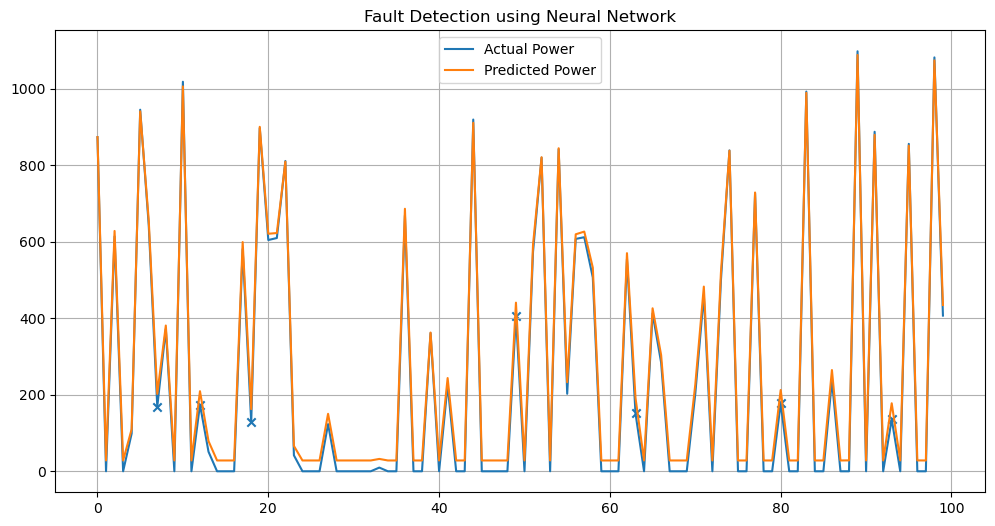

In [37]:
plt.figure(figsize=(12,6))

faults = results['Maintenance_Required'][:100]

plt.plot(
    results['Actual_AC_Power'].values[:100],
    label='Actual Power'
)

plt.plot(
    results['Predicted_AC_Power'].values[:100],
    label='Predicted Power'
)

plt.scatter(
    faults[faults].index,
    results.loc[faults[faults].index, 'Actual_AC_Power'],
    marker='x'
)

plt.title('Fault Detection using Neural Network')

plt.legend()
plt.grid(True)

plt.show()